In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "scikit-learn",
                "matplotlib", "seaborn", "ipywidgets"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'ipywidgets'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")
print("pandas  version:", pd.__version__)
print("numpy   version:", np.__version__)

✅ All libraries imported successfully!
pandas  version: 2.2.2
numpy   version: 1.26.4


In [3]:
df = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")

print("✅ Dataset loaded successfully!")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("\nColumn names:")
for col in df.columns:
    print("  -", col)

✅ Dataset loaded successfully!
Rows    : 374
Columns : 13

Column names:
  - Person ID
  - Gender
  - Age
  - Occupation
  - Sleep Duration
  - Quality of Sleep
  - Physical Activity Level
  - Stress Level
  - BMI Category
  - Blood Pressure
  - Heart Rate
  - Daily Steps
  - Sleep Disorder


In [4]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
print("=== Data types ===")
print(df.dtypes)

print("\n=== Missing values per column ===")
missing = df.isnull().sum()
print(missing)

print("\n=== Total missing values:", missing.sum(), "===")

=== Data types ===
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

=== Missing values per column ===
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

=== Total missing values: 219 ===


In [9]:
df = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")

df['Sleep Disorder'].fillna('None', inplace=True)

print("✅ Fresh data loaded!")
print("Total rows:", len(df))
print("Missing values:", df.isnull().sum().sum())

✅ Fresh data loaded!
Total rows: 374
Missing values: 0


C:\Users\aditi\AppData\Local\Temp\ipykernel_14424\3499258449.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna('None', inplace=True)


In [10]:
df = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")

df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print("✅ Fresh data loaded!")
print("Total rows:", len(df))
print("Missing values:", df.isnull().sum().sum())

✅ Fresh data loaded!
Total rows: 374
Missing values: 0


In [11]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


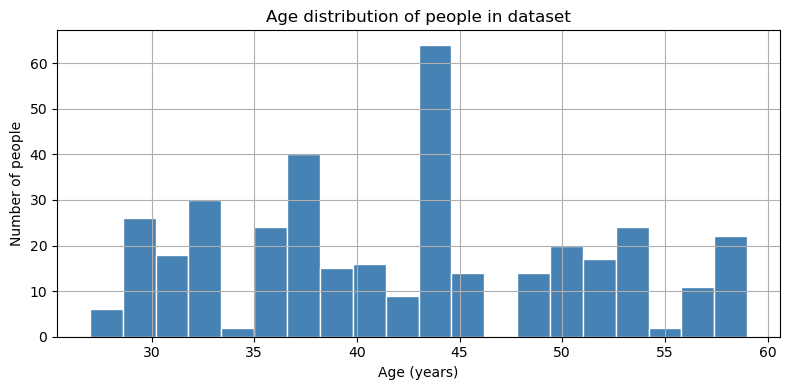

✅ Chart saved to visuals folder!


In [12]:
plt.figure(figsize=(8, 4))
df['Age'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title("Age distribution of people in dataset")
plt.xlabel("Age (years)")
plt.ylabel("Number of people")
plt.tight_layout()
plt.savefig("visuals/age_distribution.png")
plt.show()
print("✅ Chart saved to visuals folder!")

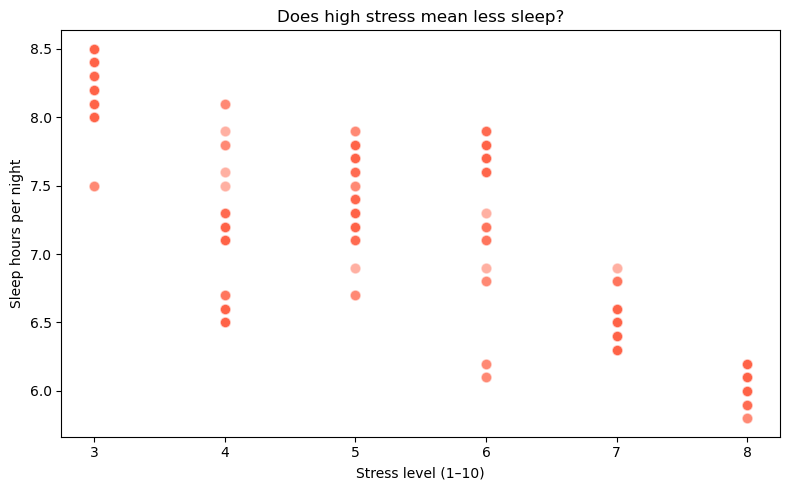

✅ Chart saved!


In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Stress Level'], df['Sleep Duration'],
            alpha=0.5, color='tomato', edgecolors='white', s=60)
plt.title("Does high stress mean less sleep?")
plt.xlabel("Stress level (1–10)")
plt.ylabel("Sleep hours per night")
plt.tight_layout()
plt.savefig("visuals/stress_vs_sleep.png")
plt.show()
print("✅ Chart saved!")

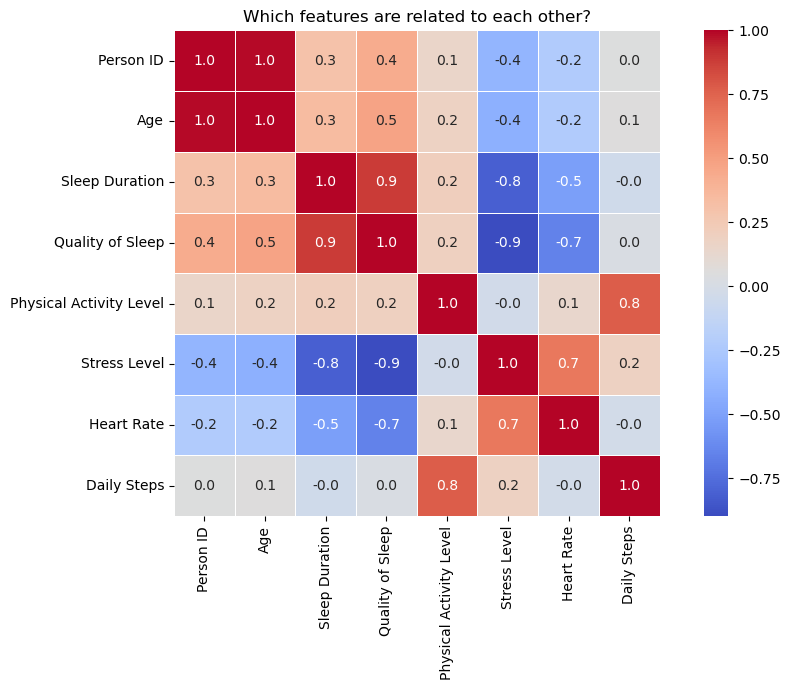

✅ Chart saved!


In [14]:
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".1f", cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title("Which features are related to each other?")
plt.tight_layout()
plt.savefig("visuals/correlation_heatmap.png")
plt.show()
print("✅ Chart saved!")